In [1]:
import os
os.getcwd()

'c:\\Users\\ugne.keliauskaite\\Bruegel GitLab\\research-2021-11-european-natural-gas-imports\\weekly updates'

In [2]:
Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Ugne
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Gio
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Ben

In [3]:
os.chdir(Share_point)

### Dependencies

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [5]:
eu27 = pd.read_excel('working_data\eu27.xlsx')

today = date.today()

d1 = '2020-01-01'
# d2 = '2023-06-30'
d2 = today.strftime("%Y-%m-%d")


converter = 10300000   ## KWh to M3m --> 10.3 KWh/m^3
converterTJ = 277778
kwhtwh = 0.000000001

In [6]:
d2

'2024-08-20'

In [7]:
(60000000*30)/1000000000

1.8

In [8]:
#manual list of points on Entsog. 
both = pd.read_excel('working_data\pointsSAFE_EU27.xlsx',sheet_name='UA')

#I am stripping out the useful part from the URL / api call. 
identifiers = []
for num in range(1,len(both['both'])):
    idt = both['both'][num][93:].split("&",1)[0]
    identifiers.append(idt)

In [9]:
both

,both
0,https://transparency.entsog.eu/api/v1/operatio...
1,https://transparency.entsog.eu/api/v1/operatio...
2,https://transparency.entsog.eu/api/v1/operatio...
3,https://transparency.entsog.eu/api/v1/operatio...
4,https://transparency.entsog.eu/api/v1/operatio...
5,https://transparency.entsog.eu/api/v1/operatio...


In [10]:
dates = []
values = []
direction = []
operator = []
point = []
labels = []

urls = []
ids = []

for idt in identifiers:
    # print(idt)
    try:
        url = 'https://transparency.entsog.eu/api/v1/operationalData?forceDownload=true&pointDirection={}&from={}&to={}&indicator=Physical%20Flow&periodType=day&timezone=CET&limit=-1&dataset=1&directDownload=true'.format(idt,d1,d2)      
        r = requests.get(url)
        data = r.json()
        op = data['operationalData']

        for item in op:
            date = item['periodFrom'][:10]
            value = item['value']
            drc = item['directionKey']
            opr = item['operatorKey']
            pt = item['pointKey']
            label = item['pointLabel']

            dates.append(date)
            values.append(value)
            direction.append(drc)
            operator.append(opr)
            point.append(pt)
            labels.append(label)
            urls.append(url)
            ids.append(idt)
            
    except Exception as e:
        print(idt)          
        # print(e)
        # print(r.status_code)

In [11]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['direction'] = direction
df['operator'] = operator
df['location'] = point
df['label'] = labels
df['country'] = df['operator'].str[:2]

In [12]:
df.replace('', np.NaN)  #we set missing values to the numpy notation, NaN - easier to work with. 
df['values'] = pd.to_numeric(df['values'])  #because of initial missing values, the dataframe column was not integer. 
#We need to set it to integer to work with. 

In [13]:
df = df.sort_values(by='dates')

In [14]:
df['location'].unique()

array(['ITP-00154', 'ITP-00307', 'ITP-00421', 'ITP-10006', 'ITP-10008',
       'ITP-00087'], dtype=object)

In [15]:
#Merge with IEA point location data. Now we also know where the gas is coming from. 
mapping = pd.read_excel('working_data\locationsSAFE.xlsx',sheet_name='UA')
mapping = mapping[['location','exportcountry']] 
dfmerge = df.merge(mapping,on='location') ## this was deleting all values not matched up ... 

#### Ukraine flows

In [16]:
dfmerge.label.unique()

array(['Ungheni', 'Beregdaróc 800 (HU) - Beregovo (UA) (HU>UA)',
       'Budince', 'VIP Bereg (HU) / VIP Bereg (UA)',
       'GCP GAZ-SYSTEM/UA TSO', 'Isaccea (RO) - Orlovka (UA) I'],
      dtype=object)

In [17]:
# fill NaNs with zeros
df= df.fillna(0)

In [18]:
# UA imports from EU
# select only the stuff we are interested into 
## Slovakia
slov = df[(df['label']=='Budince')&(df['direction']=='exit')]
slov.set_index(pd.DatetimeIndex(slov['dates']),inplace=True)
slov = slov.sort_index()
## Poland
pol = df[(df.label=='GCP GAZ-SYSTEM/UA TSO')& (df.direction == 'exit')]
pol.set_index(pd.DatetimeIndex(pol['dates']),inplace=True)
pol = pol.sort_index()
# Hungary 
hungary = ['VIP Bereg (HU) / VIP Bereg (UA)']
hung = df[(df.label.isin(hungary))&(df.operator =='HU-TSO-0001')& (df.direction == 'exit')]
hung.set_index(pd.DatetimeIndex(hung['dates']),inplace=True)
hung = hung.sort_index()
# Romania
rom = df[(df.label=='Isaccea (RO) - Orlovka (UA) I')&(df.operator=='UA-TSO-0001')]
rom.set_index(pd.DatetimeIndex(rom['dates']),inplace=True)
rom = rom.sort_index()
# Moldova
mold = df[(df.label=='Ungheni')&(df.operator=='RO-TSO-0001')]
mold.set_index(pd.DatetimeIndex(mold['dates']),inplace=True)
mold = mold.sort_index()


In [19]:
rom.replace('UA','RO',inplace=True)

In [20]:
# stay with datafram with only EU--> UA flows
df_eu = pd.concat([slov,pol,hung,rom])

In [21]:
df.country.unique()

array(['RO', 'HU', 'SK', 'PL', 'UA'], dtype=object)

In [22]:
import matplotlib.dates as mdates

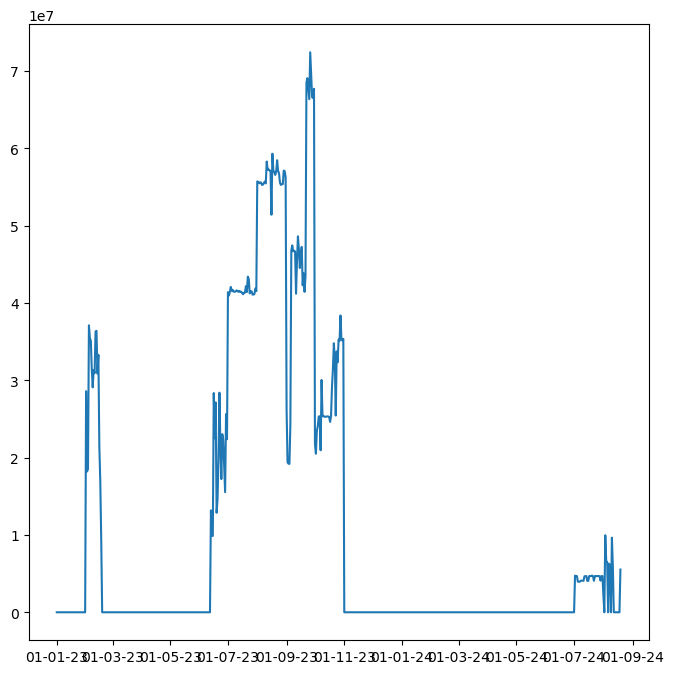

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
ro_day = rom['2023':]['values']
ax.plot(ro_day,label='Romania')
date_form1 = DateFormatter("%d-%m-%y")
ax.xaxis.set_major_formatter(date_form1)
plt.show()

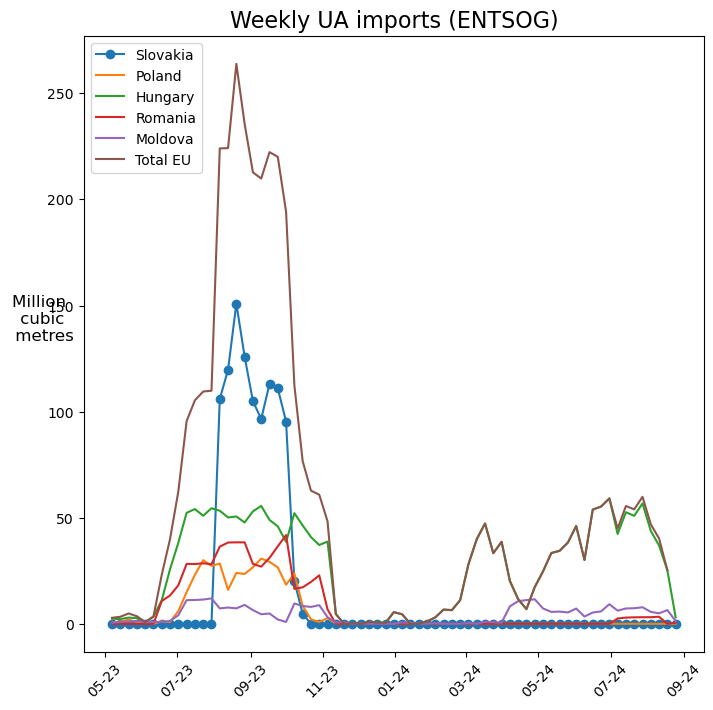

In [24]:
startdate = '2023-05-01'
enddate = today
fig, ax = plt.subplots(figsize=(8, 8))
slov_plt = slov[startdate:enddate]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
hung_plt = hung[startdate:enddate]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
pol_plt = pol[startdate:enddate]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
rom_plt = rom[startdate:enddate]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter
mold_plt = mold[startdate:enddate]['values'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)/converter

total_eu = slov_plt+hung_plt+pol_plt+rom_plt
total_eu = total_eu[startdate:enddate]

ax.plot(slov_plt, label='Slovakia',marker='o')
ax.plot(pol_plt,label='Poland')
ax.plot(hung_plt,label='Hungary')
ax.plot(rom_plt,label='Romania')
ax.plot(mold_plt,label='Moldova')
ax.plot(total_eu,label='Total EU')

date_form1 = DateFormatter("%m-%y")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)

plt.title('Weekly UA imports (ENTSOG)',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)
plt.legend(loc='upper left')

plt.show()

In [25]:
slov_plt.tail()

dates
2024-07-28    0.0
2024-08-04    0.0
2024-08-11    0.0
2024-08-18    0.0
2024-08-25    0.0
Freq: W-SUN, Name: values, dtype: float64

In [26]:
total_eu.tail()

dates
2024-07-21    53.949000
2024-07-28    59.863026
2024-08-04    46.898322
2024-08-11    40.212532
2024-08-18    25.240587
Freq: W-SUN, Name: values, dtype: float64

In [27]:
d = {'Slovakia':slov_plt,'Poland':pol_plt,'Hungary':hung_plt,'Romania':rom_plt,'Total EU':total_eu, 'Moldova':mold_plt} 
dd = pd.DataFrame(data=d)

In [28]:
import os
# os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Imports\UA imports')
os.chdir(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\Imports\UA imports')

In [29]:
df.set_index(pd.DatetimeIndex(df['dates']),inplace=True)

In [30]:
type(today)

datetime.date

In [31]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Imports\\UA imports'

In [32]:

# For countries 
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

for country in ['SK', 'RO', 'HU', 'PL']:

    ctemp = df_eu[df_eu['country'] == country]
    cplot = ctemp.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
    cplot['week'] = cplot.index.isocalendar().week

    #values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('week').max()
    #values2023 = cplot.loc['2023-01-02':].groupby('week').max()
#changes Ugne made
    values2022 = cplot.loc['2022-01-03':'2023-01-01'].groupby('week').max()
    values2023 = cplot.loc['2023-01-02':'2023-12-31'].groupby('week').max()
    values2024 = cplot.loc['2024-01-01':].groupby('week').max()

    data['{}_2022'.format(country)] = values2022
    data['{}_2023'.format(country)] = values2023
    data['{}_2024'.format(country)] = values2024 #added

eu = df_eu.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter
eu['week'] = eu.index.isocalendar().week

#tot_values2022 = eu.loc['2022-01-03':'2023-01-01'].groupby('week').max()   # before '2020-12-28':'2022-01-02'
#tot_values2023 = eu.loc['2023-01-02':enddate].groupby('week').max()  
#changes Ugne made
tot_values2022 = eu.loc['2022-01-03':'2023-01-01'].groupby('week').max()   # before '2020-12-28':'2022-01-02'
tot_values2023 = eu.loc['2023-01-02':'2023-12-31'].groupby('week').max()
tot_values2024 = eu.loc['2024-01-01':enddate].groupby('week').max() 

data['EU_2022'] = tot_values2022
data['EU_2023'] = tot_values2023
data['EU_2024'] = tot_values2024 #added Ugne

data = data.round(1)
data.to_csv(r'reverse flows into UA {}.csv'.format(today))


In [33]:
# ----------------------------------------------------------------------------------------  not needed from here down -------------------------------------------------------------------------------------------------------------

In [35]:
df_eu = df[df['country'].isin(['SK', 'RO', 'HU', 'PL'])]
eu = df_eu.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)[:enddate]/converter  

In [36]:
eu

,values
dates,
2020-01-05,58.611073
2020-01-12,81.585206
2020-01-19,85.013984
2020-01-26,97.972218
2020-02-02,131.961591
...,...
2023-12-10,0.976796
2023-12-17,0.593301
2023-12-24,0.471456


In [37]:
tot_values2022 = eu.loc['2022-01-03':'2023-01-01'] 

In [53]:
tot_values2022 = eu.loc['2022-01-03':'2023-01-01'].groupby('week').max()   # before '2020-12-28':'2022-01-02'
tot_values2023 = eu.loc['2023-01-02':enddate].groupby('week').max()  

data['EU_2022'] = tot_values2022
data['EU_2023'] = tot_values2023

KeyError: 'week'

In [29]:
dd = dd.round(2)
dd.to_csv('reverse flows into UA {}.csv'.format(today))